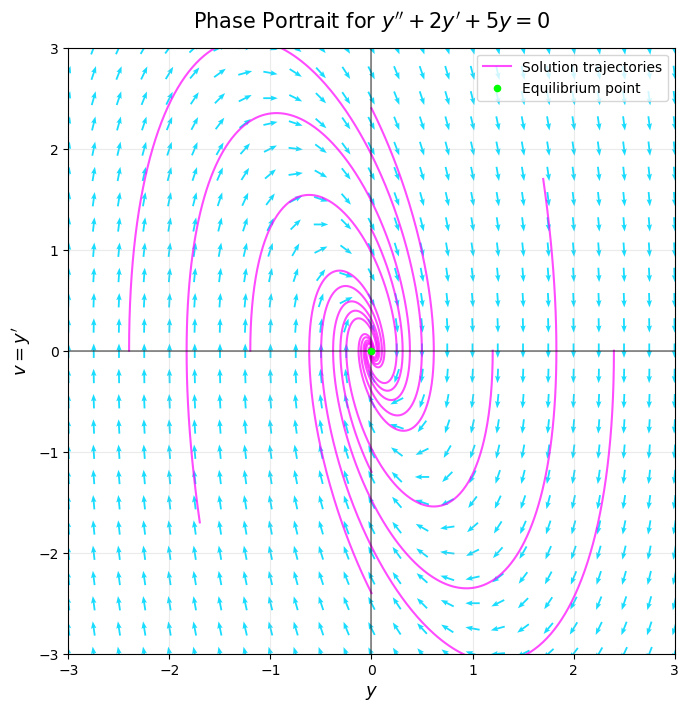

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------------------------------------------
# Phase portrait for y'' + 2y' + 5y = 0
# ---------------------------------------------------

from scipy.integrate import solve_ivp

# Grid in phase space
y = np.linspace(-3, 3, 25)
v = np.linspace(-3, 3, 25)

Y, V = np.meshgrid(y, v)

# System:
# y' = v
# v' = -2v - 5y

DY = V
DV = -2 * V - 5 * Y

# Normalize phase vectors geometrically
L = np.sqrt(DY**2 + DV**2)
L[L == 0] = 1

U = DY / L
W = DV / L

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 7),
    constrained_layout=True
)

# ---------------------------------------------------
# Phase field
# ---------------------------------------------------

ax.quiver(
    Y, V,
    U, W,
    color='#00d9ff',
    angles='xy',
    scale_units='xy',
    scale=7,
    width=0.003,
    pivot='middle',
    headwidth=3,
    headlength=4,
    headaxislength=3.5,
    alpha=0.9
)

# ---------------------------------------------------
# System function
# ---------------------------------------------------

def system(t, z):

    y, v = z

    dydt = v
    dvdt = -2*v - 5*y

    return [dydt, dvdt]

# ---------------------------------------------------
# Initial conditions
# ---------------------------------------------------

initial_conditions = [

    # Outer trajectories
    [ 2.4,  0.0],
    [ 1.7,  1.7],
    [ 0.0,  2.4],

    [-2.4,  0.0],
    [-1.7, -1.7],
    [ 0.0, -2.4],

    # Inner trajectories
    [ 1.2,  0.0],
    [-1.2,  0.0],
    [ 0.0,  1.2],
    [ 0.0, -1.2]
]

# ---------------------------------------------------
# Time values
# ---------------------------------------------------

t_span = (0, 8)
t_eval = np.linspace(0, 8, 1200)

# ---------------------------------------------------
# Plot trajectories
# ---------------------------------------------------

for i, z0 in enumerate(initial_conditions):

    sol = solve_ivp(
        system,
        t_span,
        z0,
        t_eval=t_eval
    )

    ax.plot(
        sol.y[0],
        sol.y[1],
        color='magenta',
        linewidth=1.5,
        alpha=0.7,
        label="Solution trajectories" if i == 0 else None
    )

# ---------------------------------------------------
# Equilibrium point
# ---------------------------------------------------

ax.scatter(
    0, 0,
    color='lime',
    s=20,
    label="Equilibrium point",
    zorder=5
)

# ---------------------------------------------------
# Axes
# ---------------------------------------------------

ax.axhline(0, color='black', linewidth=1.1, alpha=0.55)
ax.axvline(0, color='black', linewidth=1.1, alpha=0.55)

# ---------------------------------------------------
# Labels and title
# ---------------------------------------------------

ax.set_xlabel(r"$y$", fontsize=13)
ax.set_ylabel(r"$v = y'$", fontsize=13)

ax.set_title(
    r"Phase Portrait for $y''+2y'+5y=0$",
    fontsize=15,
    pad=14
)

# ---------------------------------------------------
# Limits and aspect ratio
# ---------------------------------------------------

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

ax.set_aspect('equal', adjustable='box')

# ---------------------------------------------------
# Grid
# ---------------------------------------------------

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.8
)

# ---------------------------------------------------
# Legend
# ---------------------------------------------------

ax.legend(
    fontsize=10,
    loc='upper right'
)

plt.show()